In [36]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from concurrent.futures import ProcessPoolExecutor
vector.register_awkward()

NanoAODSchema.warn_missing_crossrefs = False

file = '/gv0/Users/achihwan/SKNano/ggHtogamgam/44BD3ABD-AE09-4C46-BB4E-D16BEE4244EE.root'

events = NanoEventsFactory.from_root(
    {file: "Events"},
    schemaclass=NanoAODSchema,
    mode="eager"
).events()



KeyboardInterrupt: 

AttributeError: no field named 'pdgid'

[33.1, 58.9, 80.3, 36.4, 43.3, 33.9, ..., 37.1, 7.32, 33, 35.9, 32.6, 36.8]
[33.1, 29, 77, 36.4, 43.3, 33.9, 7.38, ..., 37.1, 7.32, 33, 35.9, 32.6, 58.3]


(array([1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00,
        1.0000e+00, 3.0000e+00, 2.0000e+00, 7.0000e+00, 3.0000e+00,
        7.0000e+00, 1.5000e+01, 1.5000e+01, 3.3000e+01, 5.8000e+01,
        9.9000e+01, 1.8600e+02, 3.1900e+02, 5.5500e+02, 1.0993e+04,
        4.8200e+02, 5.6700e+02, 3.6400e+02, 1.6600e+02, 1.0000e+02,
        5.1000e+01, 3.8000e+01, 2.5000e+01, 1.9000e+01, 8.0000e+00,
        7.0000e+00, 4.0000e+00, 2.0000e+00, 3.0000e+00, 0.0000e+00,
        2.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 2.0000e+00]),
 array([-2.57229980e+02, -2.46938141e+02, -2.36646286e+02, -2.26354446e+02,
        -2.16062592e+02, -2.05770752e+02, -1.95478912e+02, -1.85187073e+02,
        -1.74895218e+02, -1.64603363e+02, -1.54311523e+02, -1.44019684e+02,
        -1.33727844e+02, -1.23435989e+02, -1.13144150e+02, -1.02852295e+02,
        -9.256

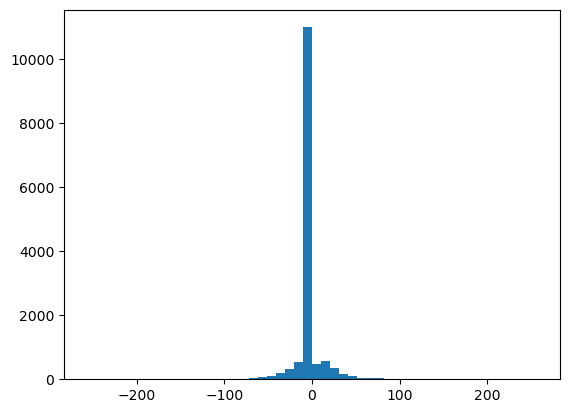

In [ ]:
pdgid = events.LHEPart.pdgId
muon = abs(pdgid)==22
lhemuon = events.LHEPart[muon]
twomuonfilter = ak.num(lhemuon)>1
lhemuon = lhemuon[twomuonfilter]
lead = lhemuon[:,0]
sublead = lhemuon[:,1]
print(lead.pt)
print(sublead.pt)
dpt = (lead.pt-sublead.pt)

plt.hist(dpt,bins = 50 )
#plt.hist(lead.pt)
#plt.hist(sublead.pt)